# Radiometric correction

> **Radiometric Correction:** A set of techniques applied to modify the original DN (digital numbers) of a satellite image in order to bring them closer to the values that would be recorded under ideal reception conditions (Chuvieco, 2008).  

The intensity of the signal received by the sensor is not solely a function of the **optical properties of the surface it interacts with**. Anomalies in radiance may be due to:

- Failures in the calibration of the sensor’s detectors;  
- Influence of the atmosphere;  
- Illumination/observation geometry, mainly determined by:  
  - Solar elevation  
  - Slope and topographic orientation

The radiometric correction applied in this notebook aims to address anomalies resulting from the interaction of radiation with the atmosphere (**atmospheric correction**) and variations in illumination/observation geometry (**topographic correction**).  

> If interferences in the signal are not removed, variations in the image’s reflectivity could be due to differences in land cover or to different atmospheric and illumination conditions.

In [1]:
# 1. Handle tiff images
from pathlib import Path
import rasterio
import numpy as np
import math
from xml.dom import minidom
# 2. Perform atmospheric correction
import ee
from Py6S import *
# 4. Visualization
from matplotlib import pyplot as plt
# 5. Dates operations
from datetime import datetime

## GEOSAT Dataset

The next code has been developed to test the radiometric correction over GEOSAT image with the following properties:

- PM4 o *Bundle*: Panchromatic image (1m GSD), and four multispectral bands (3m GSD)
- Treatment level L1C: **Calibrated, radiometrically corrected** and orthorectified.

| Band | Min $\lambda$ (nm) | Max $\lambda$ (nm) | GSD (m) |
| ----- | ------------------ | ------------------ | ------- |
| PAN   | 560                | 900                | 0.75    |
| BLUE  | 466                | 525                | 3       |
| GREEN | 532                | 599                | 3       |
| RED   | 640                | 697                | 3       |
| NIR   | 770                | 892                | 3       |

**Important**: The directory structure with the images should have the following files:

```text
DE2_PM4_L1C_000000_20210629T102606_20210629T102608_DE2_38083_838B
|_ DE2_MS4*.dim
|_ DE2_MS4*.tif
|_ DE2_PAN*.dim
|_ DE2_PAN*.tif
```

### Load image with `rasterio`

In [ ]:
img_path = r"C:\path\to\geosat_img"
img_name = "DE2_MS4_L1C_000000_20210629T102606_20210629T102608_DE2_38083_838B"

with rasterio.open(Path(img_path, img_name + '.tif')) as src:
    # Image metadata
    img_meta = src.meta
    img_shape = src.shape # (rows, cols)
    # Store the image inside numpy array
    img_array = src.read()
    img_bbox = src.bounds

print("Image dimensions. (row, col):", img_shape)
print("Data type:", img_array.dtype)

Dimensiones de la imgn. (filas, columnas): (5616, 5292)
Tipo de dato: uint16


## Absolute Radiometric Correction

GEOSAT images are stored in digital levels (DN, values that do not represent comparable magnitudes). This means that values cannot be directly compared between different bands:

> A value of 5 units in band 1 may be greater or smaller than a value of 20 units in band 2.

For this reason, the first step in atmospheric correction is to transform these digital values into physical units that are comparable to each other. This process converts DN values into radiance values. The sensor transforms the radiance reflected by the Earth's surface into DN values, which are linearly related to radiance. This correlation (depending on the observation band) is calculated by the company, modeling the coefficients of the linear equation that defines this relationship.

$$y = s * m + c$$

or

$$L = GAIN * ND + BIAS$$

The coefficients $GAIN$ and $BIAS$ are found in the `.dim` file, an XML-structured file that contains the image metadata. They will be extracted using Python's `minidom` module.

Each spectral band has its own `<Spectral_Band_Info>` section, where specific data is stored, including the coefficients needed for the ARC operation.

In [6]:
# Open image metadata file
dim_path = Path(img_path, img_name + ".dim")
geosat_metadata_dim = minidom.parse(str(dim_path))

# Empty dict to store band properties
geosat_bands_meta = {}
# Get all the band XML elements
spec_band_info = geosat_metadata_dim.getElementsByTagName('Spectral_Band_Info')
print("Bands founded:", len(spec_band_info))

# Store all the band keys
for node in spec_band_info:
    band_dict = {}
    for el in node.childNodes:
        if el.nodeType == minidom.Node.ELEMENT_NODE:
            band_dict[el.tagName] = el.childNodes[0].data
  
    # Store band dict
    geosat_bands_meta[int(band_dict['BAND_INDEX'])] = band_dict

print("Band 1 metadata:", geosat_bands_meta[1])

Bands founded: 4
Band 1 metadata: {'BAND_INDEX': '1', 'BAND_DESCRIPTION': 'NIR', 'PHYSICAL_GAIN': '0.006800104616', 'PHYSICAL_BIAS': '-0.00680010461', 'PHYSICAL_UNIT': 'W m<sup>-2</sup> &micro;m<sup>-1</sup> str<sup>-1</sup>', 'ESUN': '1076.885158'}


Once the metadata for each band is obtained, the ARC formula is applied individually using the specific coefficients for each band.

In [4]:
img_radiance = np.empty((img_meta['count'], img_shape[0], img_shape[1]))
for b in range(img_meta['count']):
    bias = float(geosat_bands_meta[b+1]['PHYSICAL_BIAS'])
    gain = float(geosat_bands_meta[b+1]['PHYSICAL_GAIN'])
    img_radiance[b] = (img_array[b] * gain) + bias

By comparing the maximum radiance values with the maximum DN values, the need for ARC correction becomes evident. In the original image with DN values, the maximum occurs in the infrared band, whereas after applying the correction, the maximum shifts to the green band.

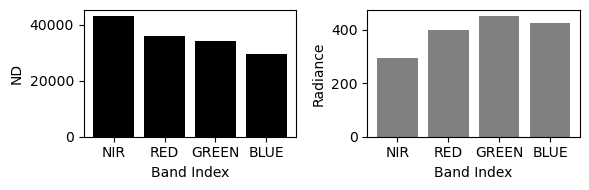

In [5]:
# Compute the max values in each band
nd_max = np.max(img_array, axis=(1, 2))
rd_max = np.max(img_radiance, axis=(1, 2))
# Write image band names (from metadata object)
img_bands = [v['BAND_DESCRIPTION'] for k, v in geosat_bands_meta.items()]

fig, axs = plt.subplots(1, 2, figsize=(6,2))
# Plot digital levels max values
axs[0].bar(range(1, 5), nd_max, color='black')
axs[0].set_xticks(range(1, 5), labels=img_bands)
axs[0].set_xlabel("Band Index")
axs[0].set_ylabel("ND")
# Plot radiance units
axs[1].bar(range(1, 5), rd_max, color='grey')
axs[1].set_xticks(range(1, 5), labels=img_bands)
axs[1].set_xlabel("Band Index")
axs[1].set_ylabel("Radiance")
fig.tight_layout()

## Atmospheric Correction (6S)

Converting radiance to *apparent* reflectance by correcting the atmospheric effect.

> **Reflectance**: The ratio between the amount of solar energy reaching a surface and the amount of energy reflected back.

- **Reflected energy**: Radiance captured by the sensor.
- **Incident energy**: Solar irradiance (parameter **ESUN**).

The **6S model** is based on a set of **reference atmospheres**. Depending on the atmospheric conditions at the time of image capture (derived from specific atmospheric parameters) the model selects the reference atmosphere that best matches the conditions and calculates the effects of **scattering and absorption** accordingly.

This is a **radiative transfer model**, as the reference atmospheres have been computed through **simulations of electromagnetic radiation propagation in the atmosphere, using atmospheric soundings or standard atmospheric models**.

In [7]:
# Init the 6S model instance, where parameters to run the model are stored
s = SixS()

In Python, this model has been compiled using the [`Py6S`](https://py6s.readthedocs.io/en/latest/) package. Execution starts by defining the `SixS` class, which serves as an object where all the required parameters for the model calculation must be stored.

All input data will be collected based on the **centroid of the image** (e.g., altitude, water vapor, etc.).

**Types of Data to Collect:**

1. **Image and illumination-observation geometry properties**
2. **Atmospheric conditions at the time of capture**

### Image geometry properties

Some of the required data can be found in the `.dim` file containing the image metadata.

The **satellite azimuth angle** (`SATELLITE_AZIMUTH`) is located within the `Quality_Parameter` property.

```xml
<Quality_Parameter>
    <QUALITY_PARAMETER_DESC>SATELLITE_AZIMUTH</QUALITY_PARAMETER_DESC>
    <QUALITY_PARAMETER_CODE>GEOSAT:SAA</QUALITY_PARAMETER_CODE>
    <QUALITY_PARAMETER_VALUE>78.8468299081</QUALITY_PARAMETER_VALUE>
</Quality_Parameter>
```

In [8]:
# Get satellite azimuth
quality_tags = geosat_metadata_dim.getElementsByTagName('Quality_Parameter')

# Iterate over all the Quality_Parameter tags
for node in quality_tags:
    # Retrieve the Quality Parameter label (description tag)
    quality_desc = node.getElementsByTagName('QUALITY_PARAMETER_DESC')
    # Get the description (text data inside the tag)
    description = quality_desc[0].firstChild.data
    if description == 'SATELLITE_AZIMUTH':
        value = node.getElementsByTagName('QUALITY_PARAMETER_VALUE')
        azimuth = float(value[0].firstChild.data)
print("Satellite Azimuth (Degrees):", azimuth)

Satellite Azimuth (Degrees): 78.8468299081


The remaining metadata can be located directly by the XML tag name. While the previous metadata was stored as text within a generic XML tag (e.g., `Quality_Parameter`), the rest of the metadata to be collected is found within the **tag name itself**.  

```xml
<Scene_Source>
    <SUN_ELEVATION unit="DEG">61.7363</SUN_ELEVATION>
    <PIXEL_RESOLUTION_X unit="M">3.0</PIXEL_RESOLUTION_X>
    <PIXEL_RESOLUTION_Y unit="M">3.0</PIXEL_RESOLUTION_Y>
    <SUN_AZIMUTH unit="DEG">124.72841377</SUN_AZIMUTH>
    <EARTH_SUN_DISTANCE unit="AU">1.01663</EARTH_SUN_DISTANCE>
</Scene_Source>
```

The following function extracts the above parameters inside a dictionary.

In [9]:
get_global_tag = lambda key, dim: dim.getElementsByTagName(key)[0].firstChild.data

meta_global_tags = [
    'SUN_AZIMUTH',
    'SUN_ELEVATION',
    'START_TIME',
    'VIEWING_ANGLE',
    'EARTH_SUN_DISTANCE'
]

geosat_scene_meta = [get_global_tag(t, geosat_metadata_dim) for t in meta_global_tags]
# zip construct an object with dict(name = "John", age = 36, country = "Norway")
geosat_scene_meta = dict(zip(meta_global_tags, geosat_scene_meta))
geosat_scene_meta['SATELLITE_AZIMUTH'] = azimuth
print(geosat_scene_meta)

{'SUN_AZIMUTH': '124.72841377', 'SUN_ELEVATION': '61.7363', 'START_TIME': '2021-06-29T10:26:06', 'VIEWING_ANGLE': '2.77621379891', 'EARTH_SUN_DISTANCE': '1.01663', 'SATELLITE_AZIMUTH': 78.8468299081}


Once the image geometry properties are extracted, these are included inside the 6S model object.

In [10]:
date_format = '%Y-%m-%dT%H:%M:%S'
scene_date = datetime.strptime(geosat_scene_meta['START_TIME'], date_format)
# Zenith solar angle is the complement angle of sun elevation)
solar_z = 90 - float(geosat_scene_meta['SUN_ELEVATION'])

# Earth-Sun-satellite geometry
s.geometry = Geometry.User()
# Set the sensor view as NADIR (0 degrees)
s.geometry.view_z = 0
# Solar zenith angle
s.geometry.solar_z = solar_z
# Day and month when image was taken, to compute earth-sun distance
s.geometry.month = scene_date.month 
s.geometry.day = scene_date.day
# Make default satellite elevation
s.altitudes.set_sensor_satellite_level()

In addition, it is necessary to include the **average height of the scene**. This can typically be obtained using the [SRTM dataset](https://developers.google.com/earth-engine/datasets/catalog/USGS_SRTMGL1_003?hl=es-419), a global DEM at 30m resolution, along with the Google Earth Engine API.

In [ ]:
# Init the Google Earth Engine Python API
ee.Authenticate()
ee.Initialize(project="project-id")

dataset = ee.Image('USGS/SRTMGL1_003')
elevation = dataset.select('elevation')

The next step is compute the image bounding box in GEE and retrieve the scene altitude. In order to include the bounding box in GEE, the CRS should be transformed from the local image CRS to a global EPSG:4326 degree system.

In [13]:
# Transform the original BBOX to global CRS, lat/long
from rasterio.warp import transform_bounds
from rasterio.crs import CRS
img_bbox_4326 = transform_bounds(
    img_meta['crs'],
    CRS.from_epsg(4326),
    #  left, bottom, right, top
    img_bbox.left,
    img_bbox.bottom,
    img_bbox.right,
    img_bbox.top)
# Create a dictionary with the new bounding box in EPSG:4326
coords_list = ["x_min", "y_min", "x_max", "y_max"]
bbox_4326 = dict(zip(coords_list, img_bbox_4326))
print(bbox_4326)

{'x_min': -0.78329801557842, 'y_min': 42.252386755222865, 'x_max': -0.5851936994033101, 'y_max': 42.407888282415755}


Create a new EE object with the bounding box. Giving the documentation of [ee.Geometry.Rectangle](https://developers.google.com/earth-engine/apidocs/ee-geometry-rectangle):

> The minimum and maximum corners of the rectangle, as a list of two points each in the format of GeoJSON 'Point' coordinates, or a list of two ee.Geometry objects describing a point, or a **list of four numbers in the order xMin, yMin, xMax, yMax**.

In [14]:
region = ee.Geometry.Rectangle(list(bbox_4326.values()))
type(region)

ee.geometry.Geometry

Lastly, the heigh of the image is extracted (related with the image center) and inserted inside 6S object.

In [17]:
elv = elevation.reduceRegion(reducer = ee.Reducer.mean(), geometry = region.centroid())
# Retrieve elevation from above GEE object
elv_km = elv.get('elevation').getInfo() / 1000 # i.e. Py6S uses units of kilometer
s.altitudes.set_target_custom_altitude(elv_km)

### Atmospheric conditions

To obtain the necessary atmospheric parameters for the **6S model** calculation, the **Earth Engine API** is used.

It's important to note that the syntax of the Python API differs from that of JavaScript. For more information, you can refer to the [introductory tutorial for the Earth Engine Python API](https://developers.google.com/earth-engine/tutorials/community/intro-to-python-api).

The **6S model** requires atmospheric parameters, which are collected through Google Earth Engine collections using the `atmospheric.py` module. This module contains functions created by [Sam Murphy](https://github.com/samsammurphy/gee-atmcorr-S2/blob/master/bin/atmospheric.py). The process carried out by these functions is as follows:

1. **Select the collection** and filter it by **date** and the **study area** of the image to be corrected.
2. Retrieve the **central value**.
3. Convert the value to the **units required by the 6S model**.

**Make sure to include the `atmospheric.py` file in the same directory as this notebook.**

In [20]:
from atmospheric import Atmospheric as atm

The three atmospheric parameters to include in the **6S model** are obtained from the following Google Earth Engine collections, which provide **daily data** for the following:

1. **Water Vapor**: The weight of the atmospheric water vapor column (measured in \( kg/m^2 \)).
   - Collection: **['NCEP_RE/surface_wv']**  
     - Spatial resolution of images: 278,300 meters  
     - Dataset link: [NCEP_RE surface_wv](https://developers.google.com/earth-engine/datasets/catalog/NCEP_RE_surface_wv)  

2. **Ozone**: Ozone content (measured in **Dobson units**).  
   - Collection: **['TOMS/MERGED']**  
     - Spatial resolution of images: 111,000 meters  
     - Dataset link: [TOMS MERGED](https://developers.google.com/earth-engine/datasets/catalog/TOMS_MERGED)  

3. **Aerosol Optical Thickness (AOT)**: The **Aerosol_Optical_Depth_Land_Ocean_Mean_Mean** band contains AOT data at 0.55 micrometers.  
   - Collection: **MODIS ['MODIS/061/MOD08_M']**  
     - Spatial resolution: 111,320 meters  
     - Product: Monthly  
     - Dataset link: [MODIS MOD08_M](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD08_M3)  

> **Note**: Given the **end of life of the MODIS satellite**, it is necessary to find an alternative source for obtaining AOT data.

In [21]:
scene_date_ee = ee.Date(scene_date)
h2o = atm.water(region, scene_date_ee).getInfo()
o3 = atm.ozone(region, scene_date_ee).getInfo()
aot = atm.aerosol(region, scene_date_ee).getInfo()

In [22]:
print("Water vapour (g/cm^2):", h2o)
print("Ozone (milli-atm-cm):", o3)
print("Aerosol Optical Thickness (0 - 1):", aot)

Water vapour (g/cm^2): 2.05
Ozone (milli-atm-cm): 0.319
Aerosol Optical Thickness (0 - 1): 0.195


Once the **atmospheric parameters** are calculated, they are included in the **6S model's input parameters**. This step is carried out by calling two different classes:

1. **`AtmosProfile.UserWaterAndOzone`**: This class is used to obtain a reference atmospheric profile that closely matches the calculated atmospheric values (for water vapor and ozone). It helps set the atmospheric conditions for the 6S model based on the retrieved parameters.

2. **`AeroProfile.Continental`**: This class defines the aerosol model to be used, specifically setting it to the **continental aerosol model**. This choice is made because continental aerosol types are commonly used for global applications, especially for land-based data.

In [19]:
# Componentes atmosfericos
s.atmos_profile = AtmosProfile.UserWaterAndOzone(h2o, o3)
s.aero_profile = AeroProfile.Continental
s.aot550 = aot

### Wavelengths

Atmospheric correction must be performed individually for each **sensor band** because **atmospheric absorption and scattering** are highly dependent on the **wavelength** at which energy is detected.

To include the wavelength in the **6S model**, it is necessary to obtain the **spectral response** of the sensor bands. The spectral response for **Sentinel-2 or Landsat bands** are provided within the **Py6S module** in the [PredefinedWavelengths](https://github.com/robintw/Py6S/blob/master/Py6S/Params/wavelength.py#L134) object. However, there is no information available for **GEOSAT bands**, so these will have to be defined manually.

The [`Py6S.Wavelength`](https://github.com/robintw/Py6S/blob/master/Py6S/Params/wavelength.py) object allows the inclusion of the spectral response for a band. The required parameters are the **start** and **end wavelengths** detected by the band (in micrometers). 

The spectral responses for the **GEOSAT sensor** are provided in the [user manual, p. 4](https://earth.esa.int/eogateway/documents/20142/37627/GEOSAT-2-Imagery-User-Guide.pdf).

To make this process easier, a function that selects the spectral response for the **target band** is defined.

In [23]:
[v['BAND_DESCRIPTION'] for k, v in geosat_bands_meta.items()]

['NIR', 'RED', 'GREEN', 'BLUE']

In [26]:
def spectralResponseFunction(bandname):
    # [lowerBandEdge, upperBandEdge]
    band_select = {
        'NIR': [0.770, 0.892],
        'RED': [0.640, 0.697],
        'GREEN': [0.532, 0.599],
        'BLUE': [0.466, 0.525],
        'PAN': [0.560, 0.900]
    }
    start_wavelength = band_select[bandname][0]
    end_wavelength = band_select[bandname][1]
    return Wavelength(start_wavelength, end_wavelength)

### Run 6S model

To execute the **6S model** and perform the **atmospheric correction**, the process involves selecting the reference atmosphere that most closely matches the conditions at the time of image capture. From this **reference atmosphere**, the required atmospheric unknowns ($\tau$, $E_{\text{dir}}$, $E_{\text{dif}}$, and $L_p$) are obtained.

The atmospheric correction is performed by applying the **radiative transfer equation**:

$$
\rho_{\text{BOA}} = \frac{\pi (L_\lambda - L_p)}{\tau(E_{\text{dir}} + E_{\text{dif}})}
$$

where:

- $L_\lambda$ = **radiance** captured by the sensor at a specific wavelength.
- $L_p$ = *path radiance*.
- $E_{\text{dir}}$ = **direct solar irradiance**.
- $E_{\text{dif}}$ = **diffuse solar irradiance**.
- $\tau$ = **transmissivity** of the atmosphere.

**Important**: To obtain $\rho_{\text{BOA}}$, radiance values ($L_\lambda$) need to be included. The values from the GEOSAT image are already in radiance units, thanks to the **ARC correction**.

The following function will execute the **6S model**, retrieve the required atmospheric parameters, and apply the **radiative transfer function** to the radiance values.

In [24]:
def surface_reflectance(band_rad, bandname, s):
    """
    Compute surfance reflectance by wavelength.

    :band_rad: Radiance band in numpy.array format.
    :bandname: Descriptor band name from dim metadata (e.g. NIR)
    :s: Py6S object
    """
    s.wavelength = spectralResponseFunction(bandname)
    # Execute the model
    s.run()

    # Extract required parameters from the model
    Edir = s.outputs.direct_solar_irradiance
    Edif = s.outputs.diffuse_solar_irradiance
    # Path radiance
    Lp   = s.outputs.atmospheric_intrinsic_radiance
    absorb  = s.outputs.trans['global_gas'].upward
    scatter = s.outputs.trans['total_scattering'].upward
    # Total transmissivity
    tau2 = absorb*scatter
    
    print(f'Atmospheric unknowns from band {bandname}:')
    print(f'- Direct solar irradiance: {Edir}')
    print(f'- Diffuse solar irradiance: {Edif}')
    print(f'- Path radiance: {Lp}')
    print(f'- Transmissivity: {tau2}')

    # Apply equation to convert radiance to apparent reflectance (BOA)
    ref = ( (band_rad - Lp) * math.pi ) / (tau2 * ( Edir + Edif ))

    return ref

### Apply correction by band

The radiative transfer equation converts the radiance value into BOA reflectivity (*Bottom of Atmosphere*), eliminating the effect of atmospheric scattering. The equation includes four atmospheric unknowns, which will be calculated by the model based on the wavelength.

In [27]:
# Empty image where corrected bands are stored
img_boa = np.empty((img_meta['count'], img_shape[0], img_shape[1]))
# Apply correction by band
for key, values in geosat_bands_meta.items():
    bandname = values['BAND_DESCRIPTION']
    print("Correct band ", bandname)
    print("-----------------------------")
    # The band key from dim metadata is 1 based, and img index 0 based
    band_i = key - 1
    band_rad = img_radiance[band_i, :, :]
    band_boa = surface_reflectance(band_rad, bandname, s)
    # Add atmospherically corrected band to final image
    img_boa[band_i] = band_boa
    print("\n")

Correct band  NIR
-----------------------------
Atmospheric unknowns from band NIR:
- Direct solar irradiance: 519.353
- Diffuse solar irradiance: 307.528
- Path radiance: 10.694
- Transmissivity: 0.9243758160000001


Correct band  RED
-----------------------------
Atmospheric unknowns from band RED:
- Direct solar irradiance: 698.786
- Diffuse solar irradiance: 459.109
- Path radiance: 19.443
- Transmissivity: 0.906203914


Correct band  GREEN
-----------------------------
Atmospheric unknowns from band GREEN:
- Direct solar irradiance: 784.405
- Diffuse solar irradiance: 573.096
- Path radiance: 30.898
- Transmissivity: 0.8841423944


Correct band  BLUE
-----------------------------
Atmospheric unknowns from band BLUE:
- Direct solar irradiance: 778.151
- Diffuse solar irradiance: 643.98
- Path radiance: 46.474
- Transmissivity: 0.882929866




The accuracy of the model can be checked by looking at the value of **Path radiance**. Shorter wavelengths (e.g., blue) should have a higher value compared to longer wavelengths (e.g., NIR). This is due to the selective scattering effect caused by the particles that make up the atmosphere (Rayleigh scattering).

### Show results

In [28]:
def rasterio_to_imshow(img):
    img_norm = (img - img.min()) / (img.max() - img.min())  # Normalize 0-1
    img_transpose = np.transpose(img_norm, (1, 2, 0))
    # img_transpose[img_transpose == 0] = np.nan
    return img_transpose

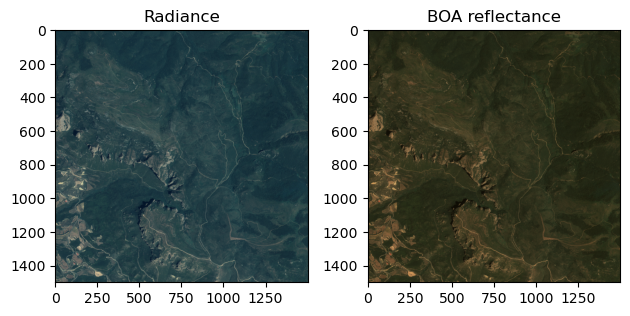

In [30]:
# Zoom in inside zoom region
zr = [1500,3000]

fig, axs = plt.subplots(1, 2)

axs[1].imshow(rasterio_to_imshow(img_boa[1:4, zr[0]:zr[1], zr[0]:zr[1]]))
axs[1].set_title("BOA reflectance")

axs[0].imshow(rasterio_to_imshow(img_radiance[1:4, zr[0]:zr[1], zr[0]:zr[1]]))
axs[0].set_title("Radiance")

fig.tight_layout()

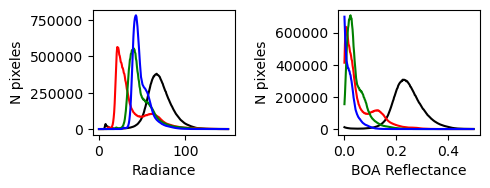

In [32]:
# Show values of each band inside an histogram
colors = ("black", "red", "green", "blue")

# Two histograms: reflectance and radiance data
fig, axs = plt.subplots(1, 2, figsize=(5,2))

# Compute radiance histogram
axs[0].set_xlabel("Radiance")
axs[0].set_ylabel("N pixeles")

# One line per band in each plot
for channel_id, color in enumerate(colors):
    histogram, bin_edges = np.histogram(
        img_radiance[channel_id, :, :], bins=256, range=(0, 150)
    )
    axs[0].plot(bin_edges[0:-1], histogram, color=color)

# Compute reflectance
axs[1].set_xlabel("BOA Reflectance")
axs[1].set_ylabel("N pixeles")

# One line per band in each plot
for channel_id, color in enumerate(colors):
    histogram, bin_edges = np.histogram(
        img_boa[channel_id, :, :], bins=256, range=(0, 0.5)
    )
    axs[1].plot(bin_edges[0:-1], histogram, color=color)

fig.tight_layout()


## Topographic Correction

To reduce the **apparent** reflectivity in BOA, it's mandatory to account for the assumptions that rarely hold true:

- The observed surface is flat (slopes less than 5%).
- All covers reflect energy equally in all directions (Lambertian surfaces).

The **Sun-Canopy-Sensor Correction + C (Soenen et al., 2005)** method is applied for this purpose.

$$
\rho_H = \rho_T \left(\frac{\cos \alpha \cdot \cos \theta_{\text{sol}} + c_{\lambda}}{IL + c_{\lambda}}\right)
$$

Where:

- $\rho_H$: **Normalized reflectivity** (for a flat surface).
- $\rho_T$: **Reflectivity** of a sloped surface (apparent reflectivity).
- $\alpha$: **Slope** (emergence angle).
- $\theta_{\text{sol}}$: **Solar zenith angle**.
- $c_{\lambda}$: **Empirical constant C**.
- $IL$: **Cosine of the local incidence angle**. 

This correction method adjusts the reflectivity by accounting for the topographic effects, particularly in forested terrain, where the slope and the local solar angle significantly influence the amount of energy reflected.

> Important: The following code is only valid if a DEM of the area is available and has the same dimensions as the image to be corrected.

### Illumination image

The cosine of the local incidence angle ($\cos\theta_{i}$), also known as the **illumination image** ($IL$), is calculated using the following formula[^1]:

[^1]: All angles are expressed in radians (*0.01745*).

$$
IL = \cos \theta_{\text{sol}} \cdot \cos \theta_{p} + \sin \theta_{\text{sol}} \cdot \sin \theta_{p} \cdot \cos (\phi_{\text{sol}} - \phi_{\text{ori}})
$$

Where:

- $\theta_p$: **Slope angle** of the terrain.
- $\phi_{\text{sol}}$: **Solar azimuth angle**.
- $\phi_{\text{ori}}$: **Terrain orientation angle**.

This equation calculates the illumination factor, which is essential for accounting for the topographic effects in the correction process, particularly in areas with varying slopes and orientations. It helps adjust the radiative transfer to reflect how the terrain interacts with solar radiation.

In [ ]:
def compute_IL(aspect, slope, az_sol, ze_sol):
    """
    :aspect: Rasterio numpy.array with aspect values (orientations)
    :slope: Rasterio numpy.array with slope (in degrees) values
    :az_sol: Azimuth solar angle from image to correct.
    :ze_sol: Image zenith solar angle.
    """
    # Transform angles into radians
    aspect_r = aspect * 0.01745
    slope_r = slope * 0.01745
    ze_sol_r = ze_sol * 0.01745
    az_sol_r = az_sol * 0.01745
    cos = lambda x: abs(math.cos(x))
    sin = lambda x: abs(math.sin(x))
    # Compute the illumination image
    il = cos(ze_sol_r) * np.cos(slope_r) + sin(ze_sol_r) * np.sin(slope_r) * np.cos(az_sol_r - aspect_r)
    return np.cos(il)

In [ ]:
dem_path = Path('C:/', "mdt.tif")
with rasterio.open(dem_path) as dst:
    dem = dst.read()

# Reshape the image with the dimension of original GEOSAT
dem_meta = img_meta.copy()
# Update band number
dem_meta['count'] = 1
# Transform the dem and store as temporal data
# It is mandatory to perform the following code
dem_temp = 'C:/dem_temp_resized.tif'
with rasterio.open(dem_temp, "w", **dem_meta) as dst:
    # Nearest neighbor resampling
    # Another options = Resampling.bilinear
    dst.write(dem, 1)

Compute aspect and slope data from DEM.

In [ ]:
from osgeo import gdal
# https://gdal.org/en/stable/api/python/utilities.html#osgeo.gdal.DEMProcessing
slope_tmp = "C:/slope.tif"
slope = gdal.DEMProcessing(slope_tmp, dem_temp, "slope", computeEdges=True)
slope_nd = np.array(slope.GetRasterBand(1).ReadAsArray())

aspect_tmp = 'C:/aspect.tif'
aspect = gdal.DEMProcessing(aspect_tmp, dem_temp, "aspect", computeEdges=True, zeroForFlat=True)
aspect_nd = np.array(aspect.GetRasterBand(1).ReadAsArray())


c:\Users\cristian\miniconda3\envs\ait_cls\Lib\site-packages\osgeo\gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


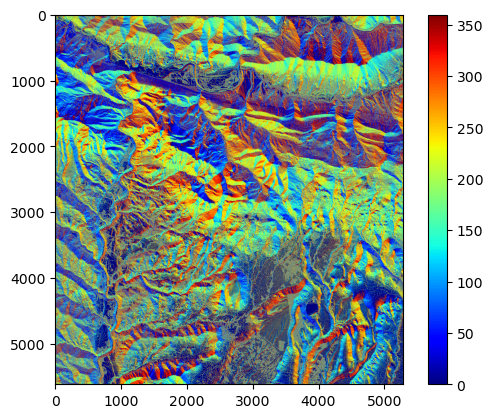

In [28]:
plt.imshow(aspect_nd, cmap="jet")
plt.colorbar()

Now the illumination image could be computed.

In [36]:
solar_z = 90 - float(geosat_scene_meta['SUN_ELEVATION'])
solar_az = float(geosat_scene_meta['SUN_AZIMUTH'])
il = compute_IL(aspect_nd, slope_nd, solar_az, solar_z)

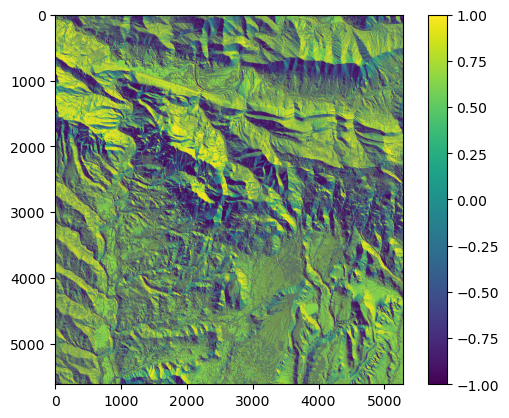

In [37]:
plt.imshow(il)
plt.colorbar()

### Constant $c$

Once the illumination image ($IL$) is calculated, the empirical constant $c$ is obtained using the following formula:

$$
c_\lambda = \frac{b_\lambda}{m_\lambda}
$$

The terms $b_\lambda$ and $m_\lambda$ are the constant and the slope of the regression line between the apparent reflectivity (dependent variable) and the illumination image (independent variable).

A custom function is defined to retrieve the coefficients by band.


In [ ]:
from scipy.stats import linregress

def compute_c(img_band, il):
    # It is mandatory transform the arrays into 1D
    lin_res_coeff = linregress(img_band.flatten(), il.flatten())
    return lin_res_coeff.intercept / lin_res_coeff.slope

### Apply topographic correction

In [37]:
def c_correction(img_band, slope, solar_z, c, il):
    """Apply c-correction to image band."""
    return img_band * ((np.cos(slope) * abs(math.cos(solar_z)) + c) / (il + c))

In [ ]:
# Empty image where corrected bands are stored
img_topo = np.empty((img_meta['count'], img_shape[0], img_shape[1]))
# Apply correction by band
for key, values in geosat_bands_meta.items():
    bandname = values['BAND_DESCRIPTION']
    print("Correct band ", bandname)
    print("-----------------------------")
    # The band key from dim metadata is 1 based, and img index 0 based
    band_i = key - 1
    band_boa = img_boa[band_i, :, :]
    band_c = compute_c(band_boa, il)
    band_topo = c_correction(band_boa, slope_nd, solar_z, band_c, il)
    # Add topographic corrected band to final image
    img_topo[band_i] = band_topo

### Comparing results

In [ ]:
# Zoom in inside zoom region
zr = [1500,3000]

fig, axs = plt.subplots(1, 3, figsize=(10,5))

axs[1].imshow(rasterio_to_imshow(img_boa[1:4, zr[0]:zr[1], zr[0]:zr[1]]))
axs[1].set_title("BOA Reflectance")
axs[1].set_axis_off()
axs[0].imshow(rasterio_to_imshow(img_radiance[1:4, zr[0]:zr[1], zr[0]:zr[1]]))
axs[0].set_title("Radiance")
axs[0].set_axis_off()
axs[2].imshow(rasterio_to_imshow(img_topo[1:4, zr[0]:zr[1], zr[0]:zr[1]]))
axs[2].set_title("BOA Reflectance + Topographic correction")
axs[2].set_axis_off()
fig.tight_layout()